# vispyx — demostración

`vispyx` es un paquete de procesamiento de imágenes cuyo núcleo es **morfología
matemática implementada desde cero**: erosión, dilatación, reconstrucción
geodésica y Zhang-Suen están escritos con bucles de NumPy, no delegados en
OpenCV ni en SciPy.

Este notebook recorre un pipeline completo y muestra la imagen en cada paso.
Como la imagen se genera acá, **sabemos cuál es la respuesta correcta**, así que
cada decisión se puede medir en vez de discutir.

Tres secciones valen tanto como el pipeline:

- **cuál de los pasos hace el trabajo de verdad** — con el error medido
- **los kernels**, y cómo cambia el resultado según la forma
- **la trampa más fácil de pisar del paquete**

```bash
pip install -e .[dev]
```

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import vispyx
from vispyx import (
    apply_clahe,
    gray_close,
    gray_tophat,
    kernel_cross,
    kernel_diamond,
    kernel_disk,
    kernel_square,
    segment_otsu,
    vpx_boundary,
    vpx_open,
    vpx_skeletonize,
)

plt.rcParams["figure.dpi"] = 72      # figuras livianas: el notebook va versionado

print("vispyx", vispyx.__version__)


def muestra(imagenes, titulos, ancho=3.0):
    """Dibuja una fila de imágenes en escala de grises, con la misma escala."""
    fig, ejes = plt.subplots(1, len(imagenes), figsize=(ancho * len(imagenes), ancho))
    for eje, imagen, titulo in zip(np.atleast_1d(ejes), imagenes, titulos):
        eje.imshow(imagen, cmap="gray", vmin=0, vmax=255)
        eje.set_title(titulo, fontsize=10)
        eje.axis("off")
    fig.tight_layout()
    plt.show()

vispyx 0.2.1


## La imagen de prueba

El repositorio ignora `archive/` y cualquier `*.pgm` o `*.png` suelto, así que
este notebook **genera su propia imagen**. No necesita datos externos.

El fantasma tiene, a propósito, los tres problemas que un pipeline morfológico
existe para resolver:

- **iluminación muy desigual** — un gradiente tan fuerte que el fondo del lado
  derecho es *más brillante* que el objeto del lado izquierdo. Cualquier umbral
  global va a fallar
- **estructura alargada y ramificada** — para que el esqueleto tenga algo que
  mostrar
- **ruido de sal** — 30 píxeles sueltos en blanco puro

`fantasma()` devuelve también la máscara exacta del objeto. Esa es la verdad
contra la que vamos a medir.

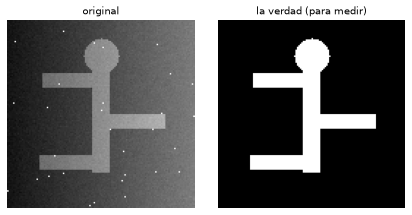

(128, 128) uint8 | rango: 8 - 255
fondo a la derecha: 113  vs  objeto a la izquierda: 112


In [2]:
def fantasma(n=128, seed=7):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:n, 0:n]

    # la verdad: donde esta el objeto, sin ruido ni iluminacion de por medio
    cuerpo = np.zeros((n, n), dtype=bool)
    for y0, y1, x0, x1 in [(22, 104, 58, 70), (36, 46, 24, 62), (64, 74, 66, 108), (92, 102, 22, 62)]:
        cuerpo[y0:y1, x0:x1] = True
    cuerpo |= (yy - 24) ** 2 + (xx - 64) ** 2 <= 12 ** 2

    imagen = (20 + 105 * (xx / n)).astype(np.float64)   # gradiente de izquierda a derecha
    imagen[cuerpo] += 70                               # el objeto, apenas 70 sobre el fondo

    for _ in range(30):                                # ruido de sal
        y, x = rng.integers(0, n, 2)
        imagen[y, x] = 255

    imagen += rng.normal(0, 4, (n, n))
    return np.clip(imagen, 0, 255).astype(np.uint8), cuerpo


original, verdad = fantasma()

muestra([original, verdad * 255], ["original", "la verdad (para medir)"])
print(original.shape, original.dtype, "| rango:", original.min(), "-", original.max())
print("fondo a la derecha:", original[10, -10], " vs  objeto a la izquierda:", original[40, 30])

Fijate en los dos números de arriba: **el fondo del lado derecho es más brillante
que el objeto del lado izquierdo.** No existe un umbral global que separe los dos.
Ese es el problema real de la imagen, y es lo que el bloque de grises tiene que
arreglar antes de que Otsu sirva de algo.

## El modelo mental: todo pipeline cruza una frontera

```
imagen de grises                        máscara binaria
────────────────                        ───────────────
apply_clahe          ──segment_otsu──►  vpx_erode / vpx_dilate
gray_erode/dilate                       vpx_open / vpx_close
gray_open/close                         vpx_gradient / vpx_boundary
gray_gradient                           vpx_tophat / vpx_blackhat
gray_tophat/blackhat                    vpx_hitmiss / vpx_reconstruct
                                        vpx_skeletonize / vpx_thin
```

A la izquierda se trabaja con **intensidad** y el dtype de la entrada se
conserva. A la derecha se trabaja con **forma**, y todo es `uint8` con valores
exactamente `{0, 255}`.

`segment_otsu` es el puente, y produce justo la convención que el lado derecho
espera.

## Paso 1 — Realce de contraste con CLAHE

`apply_clahe` ecualiza el histograma por regiones en vez de globalmente. Levanta
el contraste local sin que la zona más iluminada se lleve todo el rango.

Es de los pocos lugares donde `vispyx` delega en OpenCV: CLAHE no es una
operación morfológica.

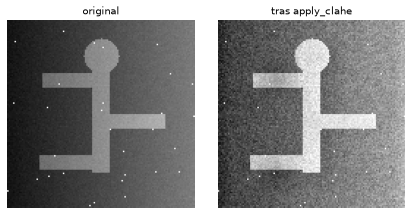

dtype: uint8 | rango: 10 - 255


In [3]:
realzada = apply_clahe(original, clip_limit=3.0, tile_grid_size=(8, 8))

muestra([original, realzada], ["original", "tras apply_clahe"])
print("dtype:", realzada.dtype, "| rango:", realzada.min(), "-", realzada.max())

## Paso 2 — Aplanar el fondo con `gray_tophat`

Este es el paso que resuelve el problema de la imagen.

Un top-hat es `imagen - apertura(imagen)`. Con un kernel **más grande que los
objetos**, la apertura se queda con el fondo y nada más; restarla deja los
objetos sobre un fondo plano. El gradiente desaparece.

El kernel es la decisión importante: `kernel_disk(13)` mide 27×27, más que la
cabeza del fantasma (24 px). Si fuera más chico que los objetos, la apertura se
los llevaría a ellos también.

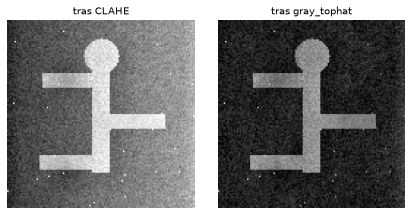

dtype de entrada: uint8 → dtype de salida: uint8
kernel_disk(13) mide (27, 27) con 529 celdas activas


In [4]:
plana = gray_tophat(realzada, kernel=kernel_disk(13))

muestra([realzada, plana], ["tras CLAHE", "tras gray_tophat"])
print("dtype de entrada:", realzada.dtype, "→ dtype de salida:", plana.dtype)
print("kernel_disk(13) mide", kernel_disk(13).shape, "con", int(kernel_disk(13).sum()), "celdas activas")

## Paso 3 — Suavizar con `gray_close`

Un cierre en escala de grises rellena los valles oscuros más chicos que el
kernel, sin mover los bordes grandes. Quita micro-huecos que después serían
agujeros en la máscara.

Las `gray_*` no binarizan nada: el dtype sigue siendo el de la entrada.

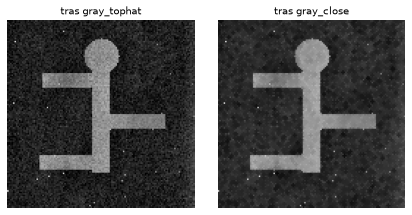

In [5]:
suave = gray_close(plana, kernel=kernel_disk(1))

muestra([plana, suave], ["tras gray_tophat", "tras gray_close"])

## Paso 4 — Cruzar la frontera con Otsu

`segment_otsu` calcula el umbral por el método de Otsu (vía scikit-image) y
binariza con NumPy. **Es la única línea del pipeline que cambia de dominio.**

De acá en adelante todo es `uint8` con valores `{0, 255}`, que es exactamente lo
que el bloque `vpx_*` espera recibir.

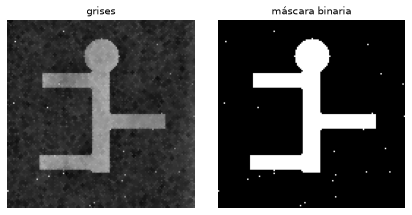

dtype: uint8
valores presentes: [  0 255]
¿solo 0 y 255? True
píxeles encendidos: 2369


In [6]:
mascara = segment_otsu(suave)

muestra([suave, mascara], ["grises", "máscara binaria"])

print("dtype:", mascara.dtype)
print("valores presentes:", np.unique(mascara))
print("¿solo 0 y 255?", set(np.unique(mascara)) <= {0, 255})
print("píxeles encendidos:", np.count_nonzero(mascara))

## Paso 5 — Limpiar la forma con `vpx_open`

Una apertura binaria es una erosión seguida de una dilatación: **borra lo que es
más chico que el kernel y deja intacto el tamaño de lo que sobrevive.** Es la
limpieza por defecto de una máscara recién segmentada.

Acá se lleva las motas de sal que sembramos al principio.

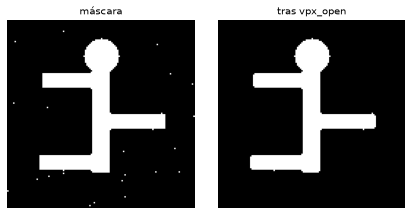

píxeles borrados por la apertura: 28
píxeles mal clasificados contra la verdad: 16
...sobre 2339 píxeles de objeto


In [7]:
limpia = vpx_open(mascara, kernel=kernel_disk(1), iterations=1)

muestra([mascara, limpia], ["máscara", "tras vpx_open"])

print("píxeles borrados por la apertura:", np.count_nonzero(mascara) - np.count_nonzero(limpia))
print("píxeles mal clasificados contra la verdad:", np.count_nonzero((limpia > 0) != verdad))
print("...sobre", verdad.sum(), "píxeles de objeto")

## Paso 6 — Extraer: contorno y esqueleto

Dos formas de reducir una región a su información esencial:

- **`vpx_boundary`** devuelve la frontera *interna*: los píxeles de primer plano
  que la erosión se come. No engorda hacia afuera.
- **`vpx_skeletonize`** aplica el adelgazamiento de Zhang-Suen hasta punto fijo,
  hasta dejar una línea de un píxel de ancho que conserva la conectividad.

Ojo con `vpx_thin`: **no** da el esqueleto. Con su default `iterations=1` hace
una sola pasada. El esqueleto completo es `vpx_skeletonize`.

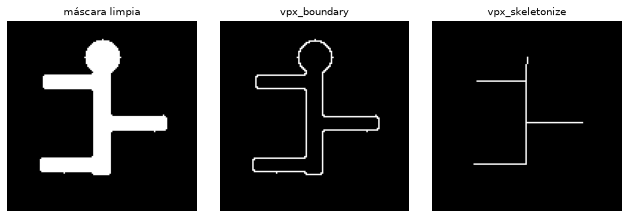

   máscara:  2341 píxeles
  contorno:   446 píxeles
 esqueleto:   179 píxeles


In [8]:
contorno = vpx_boundary(limpia)
esqueleto = vpx_skeletonize(limpia)

muestra([limpia, contorno, esqueleto], ["máscara limpia", "vpx_boundary", "vpx_skeletonize"])

for nombre, imagen in [("máscara", limpia), ("contorno", contorno), ("esqueleto", esqueleto)]:
    print(f"{nombre:>10}: {np.count_nonzero(imagen):5d} píxeles")

## El pipeline completo, de un vistazo

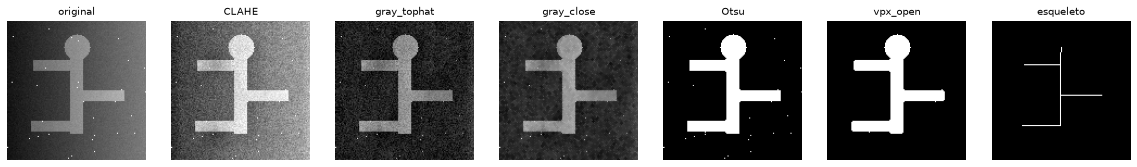

In [9]:
muestra(
    [original, realzada, plana, suave, mascara, limpia, esqueleto],
    ["original", "CLAHE", "gray_tophat", "gray_close", "Otsu", "vpx_open", "esqueleto"],
    ancho=2.3,
)

## ¿Cuál de los pasos hace el trabajo?

Como generamos la imagen, tenemos la verdad. Así que la pregunta se puede
**medir** en vez de suponer: cuántos píxeles quedan mal clasificados si sacamos
pasos del pipeline.

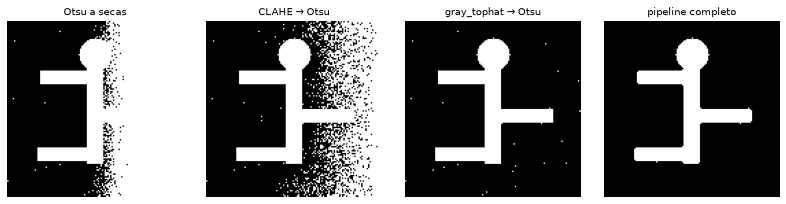

        Otsu a secas:  6636 píxeles mal clasificados
        CLAHE → Otsu:  4254 píxeles mal clasificados
  gray_tophat → Otsu:    24 píxeles mal clasificados
   pipeline completo:    16 píxeles mal clasificados


In [10]:
def error(mascara_obtenida):
    return np.count_nonzero((mascara_obtenida > 0) != verdad)


variantes = [
    ("Otsu a secas", segment_otsu(original)),
    ("CLAHE → Otsu", segment_otsu(realzada)),
    ("gray_tophat → Otsu", segment_otsu(gray_tophat(original, kernel=kernel_disk(13)))),
    ("pipeline completo", limpia),
]

muestra([m for _, m in variantes], [n for n, _ in variantes], ancho=2.8)
for nombre, m in variantes:
    print(f"{nombre:>20}: {error(m):5d} píxeles mal clasificados")

Los números dicen algo que conviene no maquillar: **el paso que resuelve el
problema es `gray_tophat`, no CLAHE.**

CLAHE mejora mucho el aspecto de la imagen y casi no mueve la aguja del
resultado. Es un recordatorio útil: en un pipeline, el paso que se *ve* más
impresionante no es necesariamente el que hace el trabajo. Por eso conviene
medir contra una verdad conocida antes de dar por bueno un preprocesamiento.

## Los kernels

El kernel decide **qué se considera vecino**, y con eso qué tan agresiva es cada
operación. Los cuatro generadores devuelven `uint8` con valores `{0, 1}`.

`size` tiene que ser impar; `kernel_disk` toma **radio**, no lado.

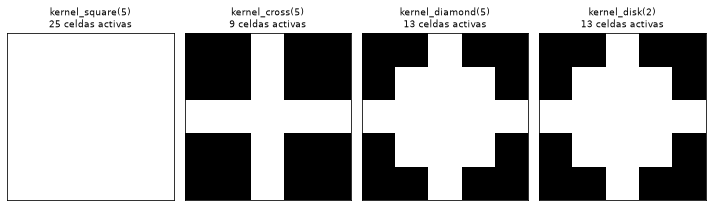

kernel_disk(1) == kernel_cross(3): True
kernel_disk(2) == kernel_diamond(5): True


In [11]:
kernels = [
    ("kernel_square(5)", kernel_square(5)),
    ("kernel_cross(5)", kernel_cross(5)),
    ("kernel_diamond(5)", kernel_diamond(5)),
    ("kernel_disk(2)", kernel_disk(2)),
]

fig, ejes = plt.subplots(1, 4, figsize=(10, 2.8))
for eje, (nombre, k) in zip(ejes, kernels):
    eje.imshow(k, cmap="gray", vmin=0, vmax=1)
    eje.set_title(f"{nombre}\n{int(k.sum())} celdas activas", fontsize=9)
    eje.set_xticks([]); eje.set_yticks([])
fig.tight_layout()
plt.show()

print("kernel_disk(1) == kernel_cross(3):", np.array_equal(kernel_disk(1), kernel_cross(3)))
print("kernel_disk(2) == kernel_diamond(5):", np.array_equal(kernel_disk(2), kernel_diamond(5)))

Que varias formas coincidan a radios chicos es geometría de la malla discreta,
no una propiedad general: a radios mayores divergen.

La regla práctica para el tamaño: **el kernel tiene que ser más chico que lo que
querés conservar y más grande que lo que querés borrar.** Si una apertura se come
el objeto, el kernel es muy grande.

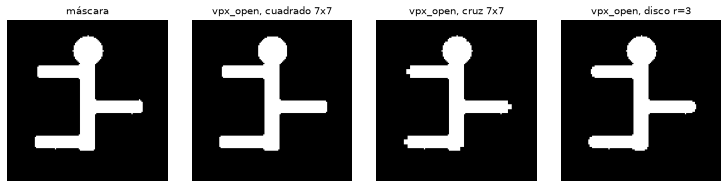

  cuadrado 7x7 (49 celdas): quedan  2335 píxeles
      cruz 7x7 (13 celdas): quedan  2282 píxeles
     disco r=3 (29 celdas): quedan  2311 píxeles


In [12]:
formas = [("cuadrado 7x7", kernel_square(7)), ("cruz 7x7", kernel_cross(7)), ("disco r=3", kernel_disk(3))]
resultados = [vpx_open(limpia, kernel=k) for _, k in formas]

muestra([limpia] + resultados, ["máscara"] + [f"vpx_open, {n}" for n, _ in formas], ancho=2.6)
for (nombre, k), resultado in zip(formas, resultados):
    print(f"{nombre:>14} ({int(k.sum()):2d} celdas): quedan {np.count_nonzero(resultado):5d} píxeles")

Los números sorprenden si uno espera que "más celdas activas" signifique "más
agresivo": el cuadrado tiene 49 celdas y es el que **menos** píxeles borra.

Lo que decide una apertura no es cuántas celdas tiene el kernel, sino **si el
kernel entra en la forma**. Las bandas del fantasma son rectángulos, y un
rectángulo sobrevive intacto a una apertura con un cuadrado: la dilatación
reconstruye las esquinas exactamente. La cruz no puede reconstruir una esquina
recta, así que se las come y pierde 59 píxeles.

La lección práctica: **elegí la forma que se parece a tus objetos.** Para
estructuras rectilíneas, cuadrado; para formas orgánicas, disco.

## La trampa: pasar una imagen de grises a una `vpx_*`

Es el error más fácil de cometer con este paquete, y **no falla**.

Las `vpx_*` binarizan su entrada con `> 0`. Sobre una imagen de grises eso
significa que **todo píxel que no sea negro puro se vuelve 255**, así que sale
una máscara casi sólida: silencio total y resultado inútil.

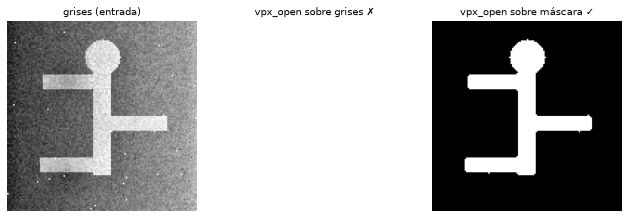

blanco tras la trampa:  100.0%
blanco haciéndolo bien:  14.3%

No hubo excepción ni aviso. Segmentá antes de entrar al bloque vpx_*.


In [13]:
trampa = vpx_open(realzada, kernel=kernel_disk(1))    # ← imagen de GRISES, sin segmentar
correcto = vpx_open(mascara, kernel=kernel_disk(1))   # ← máscara binaria

muestra([realzada, trampa, correcto], ["grises (entrada)", "vpx_open sobre grises ✗", "vpx_open sobre máscara ✓"])

print(f"blanco tras la trampa:  {100 * np.count_nonzero(trampa) / trampa.size:5.1f}%")
print(f"blanco haciéndolo bien: {100 * np.count_nonzero(correcto) / correcto.size:5.1f}%")
print("\nNo hubo excepción ni aviso. Segmentá antes de entrar al bloque vpx_*.")

## Dónde seguir

- **`docs/system_usage.md`** — la guía integral: instalación, modelo mental,
  rendimiento y trampas
- **`docs/api_reference.md`** — las 28 funciones públicas, con dtypes, contratos
  y el catálogo de errores
- **`docs/cli_reference.md`** — el comando `vispyx`, para hacer todo esto sin
  escribir Python
- **`docs/binary_morphology_usage.md`** y **`docs/grayscale_morphology_usage.md`**
  — cada operación con el algoritmo que realmente ejecuta
- **`docs/architecture.md`** — cómo está armado por dentro, si vas a modificarlo

Una advertencia antes de soltarlo sobre imágenes grandes: los motores son bucles
de Python. El costo es
`O(iterations · alto · ancho · celdas activas del kernel)`, así que una imagen de
1024×1024 con kernel 5×5 son 26 millones de reducciones — minutos, no segundos.
Por eso este notebook trabaja en 128×128. Recortá la región de interés antes de
operar.